In [ ]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint,ReduceLROnPlateau
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [3]:
PROJECT_DIR = Path.cwd().parent
DATASET_DIR = PROJECT_DIR / "dataset"

print("Project Directory:", PROJECT_DIR)
print("Dataset Directory:", DATASET_DIR)
print("Dataset exists:", DATASET_DIR.exists())

Project Directory: c:\Users\pc\Desktop\Projects\Project_1
Dataset Directory: c:\Users\pc\Desktop\Projects\Project_1\dataset
Dataset exists: True


In [4]:
for item in DATASET_DIR.iterdir():
    print(item.name)

test
train
val


In [5]:
train_dir = DATASET_DIR / "train"
val_dir = DATASET_DIR / "val"
test_dir = DATASET_DIR / "test"

print("Train:", train_dir.exists())
print("Validation:", val_dir.exists())
print("Test:", test_dir.exists())

Train: True
Validation: True
Test: True


In [6]:
classes = sorted([
    folder.name
    for folder in train_dir.iterdir()
    if folder.is_dir()
])

print("Number of classes:", len(classes))
print("\nClasses:")
for i, class_name in enumerate(classes):
    print(f"{i}: {class_name}")

Number of classes: 15

Classes:
0: beige
1: black
2: blue
3: brown
4: gold
5: green
6: grey
7: orange
8: pink
9: purple
10: red
11: silver
12: tan
13: white
14: yellow


In [7]:
class_counts = {}

for class_name in classes:
    class_path = train_dir / class_name
    
    image_count = len([
        file for file in class_path.iterdir()
        if file.is_file()
    ])
    
    class_counts[class_name] = image_count

class_counts_df = pd.DataFrame(
    list(class_counts.items()),
    columns=["Class", "Image Count"]
)

class_counts_df

,Class,Image Count
0,beige,421
1,black,406
2,blue,742
3,brown,565
4,gold,210
5,green,563
6,grey,428
7,orange,534
8,pink,483
9,purple,536


In [8]:
total_train_images = class_counts_df["Image Count"].sum()

print("Total training images:", total_train_images)

Total training images: 7267


In [9]:
def count_images(folder):
    total = 0
    
    for class_folder in folder.iterdir():
        if class_folder.is_dir():
            total += len([
                file for file in class_folder.iterdir()
                if file.is_file()
            ])
    
    return total


total_val_images = count_images(val_dir)
total_test_images = count_images(test_dir)

print("Training images  :", total_train_images)
print("Validation images:", total_val_images)
print("Test images      :", total_test_images)

Training images  : 7267
Validation images: 1550
Test images      : 1556


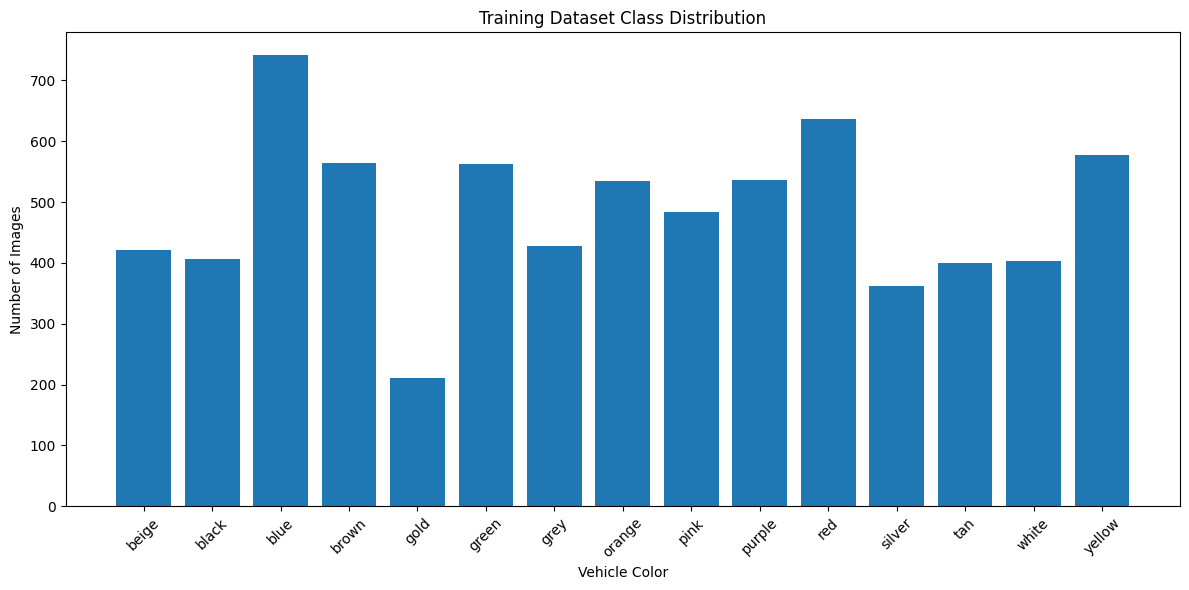

In [10]:
plt.figure(figsize=(12, 6))

plt.bar(
    class_counts_df["Class"],
    class_counts_df["Image Count"]
)

plt.xlabel("Vehicle Color")
plt.ylabel("Number of Images")
plt.title("Training Dataset Class Distribution")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

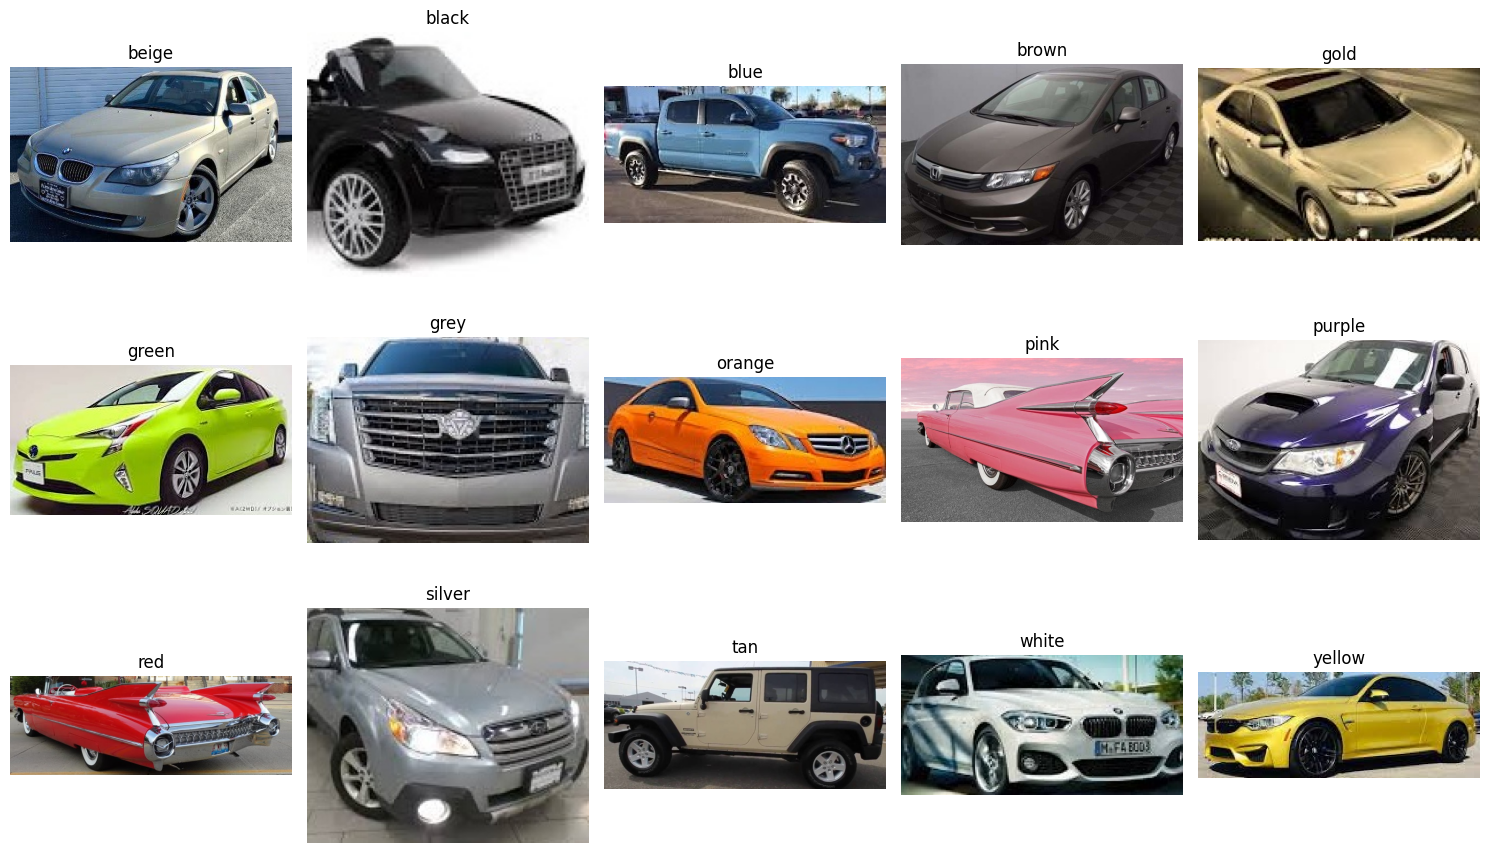

In [11]:
fig, axes = plt.subplots(3, 5, figsize=(15, 9))

for ax, class_name in zip(axes.flatten(), classes):
    
    class_path = train_dir / class_name
    
    image_files = [
        file for file in class_path.iterdir()
        if file.is_file()
    ]
    
    if image_files:
        image_path = image_files[0]
        image = Image.open(image_path).convert("RGB")
        
        ax.imshow(image)
        ax.set_title(class_name)
    
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
sample_sizes = []

for class_name in classes:
    class_path = train_dir / class_name
    
    image_files = [
        file for file in class_path.iterdir()
        if file.is_file()
    ]
    
    for image_path in image_files[:10]:
        try:
            with Image.open(image_path) as img:
                sample_sizes.append(img.size)
        except Exception:
            pass

print("Number of sampled images:", len(sample_sizes))
print("First 20 image sizes:")
print(sample_sizes[:20])

Sample image sizes:
[(430, 266), (233, 88), (159, 89), (222, 119), (320, 169), (129, 77), (637, 313), (250, 117), (233, 156), (210, 149), (137, 119), (145, 69), (249, 160), (281, 113), (932, 296), (268, 197), (234, 128), (93, 73), (259, 130), (215, 120)]


In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

print("Training dataset loaded.")

In [ ]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Validation dataset loaded.")

In [ ]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Test dataset loaded.")

In [ ]:
class_names = train_ds.class_names

print("Number of classes:", len(class_names))

print("\nClasses:")
for index, class_name in enumerate(class_names):
    print(f"{index}: {class_name}")

In [ ]:
for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("First 10 labels:", labels[:10].numpy())

In [ ]:
plt.figure(figsize=(12, 8))

for images, labels in train_ds.take(1):
    for i in range(8):
        ax = plt.subplot(2, 4, i + 1)
        
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i].numpy()])
        plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1)
])

print("Data augmentation pipeline created.")

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

print("Dataset pipeline optimized.")

In [ ]:
num_classes = len(class_names)

model = keras.Sequential([
    layers.Input(shape = (224,224,3)),
    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3,3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(256, (3,3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(2,2),

    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

In [ ]:
model.compile(
    optimizer = keras.optimizers.Adam(learning_rate = 0.001),
    loss = "sparse_categorical_crossentropy",
    metrics = ['accuracy']
)
print("Model compiled successfully.")

In [ ]:
Model_path = "Project_1/model/vehicle_color_model.h5"
print("Model will be saved at:")
print(Model_path)

In [ ]:
earlystopping = EarlyStopping(
    monitor = "val_loss",
    patience = 5,
    restore_best_weights = True,
    verbose = 1
)

model_checkpoint = ModelCheckpoint(
    Model_path,
    monitor = "val_accuracy",
    save_best_only = True,
    mode = 'max',
    verbose = 1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

In [ ]:
epochs = 50

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=[
        earlystopping,
        model_checkpoint,
        reduce_lr
    ]
)

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label = "training accuracy")
plt.plot(history.history['val_accuracy'], label = "validation accuracy")

plt.title("Training and valdation accuracy graph")
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label = "training loss")
plt.plot(history.history['val_loss'], label = "validation loss")

plt.title("Training and valdation loss graph")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
best_model = keras.models.load_model(
     "Project_1/model/vehicle_color_model.h5"
)
print("model loaded")

In [ ]:
test_loss, test_accuracy = best_model.evaluate(test_ds)
print("Test loss : ", test_loss)
print("Test accuracy : ", test_accuracy)
print("Test accuracy in percentage : ", test_accuracy * 100)

In [ ]:
y_true = []
y_predicted = []

for images, labels in test_ds :
    predictions = best_model.predict(images, verbose = 0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_predicted.extend(predicted_labels)

y_true = np.array(y_true)
y_predicted = np.array(y_predicted)

print("Total test samples:", len(y_true))

In [ ]:
cm = confusion_matrix(y_true, y_predicted)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:
print(
    classification_report(
        y_true,
        y_predicted,
        target_names=class_names
    )
)